<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/CNN_LSTM_MetroPT3_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN-LSTM Hybrid — MetroPT3
## 1D-CNN extracts local patterns → LSTM learns temporal dependencies

| Step | Content |
|---|---|
| 1 | Imports & Settings |
| 2 | Smart Data Loading |
| 3 | Preprocessing & Sequences |
| 4 | CNN-LSTM Model |
| 5 | Training |
| 6 | Evaluation & Results |
| 7 | Save Model |

> **Dataset note:** MetroPT-3 covers Feb–Aug 2020 with 4 documented failures and 15 features (no Flowmeter column).

**Why CNN-LSTM?**
- `Conv1D` acts as a **feature extractor**: detects local patterns (sudden spikes, gradual rises)
- `LSTM` then reads the extracted features **across time**: understands temporal dependencies
- Together they outperform standalone LSTM or CNN on time-series anomaly detection

## 1. Imports & Settings

In [ ]:
import os, warnings, json
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense,
                                      Dropout, BatchNormalization,
                                      GlobalAveragePooling1D, Input,
                                      Flatten, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              roc_auc_score)

os.makedirs("model/MetroPT3", exist_ok=True)
os.makedirs("output",         exist_ok=True)

# ── Settings ──────────────────────────────────────────────
DATA_PATH     = "MetroPT3.csv"
TIMESTEPS     = 30    # CNN-LSTM benefits from longer windows
BATCH_SIZE    = 512
EPOCHS        = 25
MAX_NORMAL    = 120_000
RANDOM_STATE  = 42

FAILURES = [
    ("2020-04-18", "2020-04-19", "Air Leak — Clients"),
    ("2020-05-29", "2020-05-30", "Air Leak — Dryer"),
    ("2020-06-05", "2020-06-07", "Air Leak — Clients"),
    ("2020-07-15", "2020-07-16", "Oil Leak — Compressor"),
]
WARNING_HOURS = 24

SENSOR_COLS = [
    "TP2","TP3","H1","DV_pressure","Reservoirs",
    "Oil_temperature","Motor_current","Caudal_impulse"
]

print(f"TensorFlow {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))>0}")

TensorFlow 2.21.0
GPU available: False


## 2. Smart Data Loading

In [ ]:
print("Loading MetroPT3...")
chunks_n, chunks_f, n_count = [], [], 0

for chunk in pd.read_csv(DATA_PATH, parse_dates=["timestamp"], chunksize=50_000):
    if chunk.columns[0].lower() in ["unnamed: 0", "index"]:
        chunk = chunk.drop(chunk.columns[0], axis=1)
    chunk = chunk.drop_duplicates("timestamp").sort_values("timestamp").ffill().bfill()
    ts    = chunk["timestamp"]

    chunk["label"] = 0
    for s, e, _ in FAILURES:
        t0 = pd.Timestamp(s); t1 = pd.Timestamp(e)
        tw = t0 - pd.Timedelta(hours=WARNING_HOURS)
        chunk.loc[(ts >= tw) & (ts < t0),  "label"] = 1
        chunk.loc[(ts >= t0) & (ts <= t1), "label"] = 2

    fail_part = chunk[chunk["label"] >= 1]
    norm_part = chunk[chunk["label"] == 0]

    if len(fail_part):
        chunks_f.append(fail_part)
    if n_count < MAX_NORMAL and len(norm_part):
        take = min(len(norm_part), MAX_NORMAL - n_count)
        chunks_n.append(norm_part.iloc[:take])
        n_count += take

    if n_count >= MAX_NORMAL and ts.max() > pd.Timestamp("2020-07-20"):
        break

df = (pd.concat(chunks_n + chunks_f, ignore_index=True)
        .sort_values("timestamp").reset_index(drop=True))

counts = df["label"].value_counts().sort_index()
print(f"Total  : {len(df):,}")
print(f"Normal : {counts.get(0,0):,}")
print(f"Warning: {counts.get(1,0):,}")
print(f"Failure: {counts.get(2,0):,}")
print(f"Months : {sorted(df['timestamp'].dt.month.unique())}")

Loading MetroPT3...
Total  : 187,865
Normal : 120,000
Failure: 40,849
Months : [np.int32(2), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]


## 3. Preprocessing & Sequences
> `TIMESTEPS=30` gives CNN-LSTM more temporal context to detect slow drift patterns.

In [ ]:
feat_cols = [c for c in SENSOR_COLS if c in df.columns]
print(f"Features ({len(feat_cols)}): {feat_cols}")

scaler = StandardScaler()
scaler.fit(df.loc[df["label"]==0, feat_cols])
X_sc = scaler.transform(df[feat_cols].values.astype(np.float32))
y    = (df["label"].values >= 1).astype(np.int32)

def make_sequences(X, y, ts):
    n       = len(X) - ts
    shape   = (n, ts, X.shape[1])
    strides = (X.strides[0], X.strides[0], X.strides[1])
    Xs = np.lib.stride_tricks.as_strided(X, shape=shape, strides=strides).copy()
    return Xs.astype(np.float32), y[ts:]

X_seq, y_seq = make_sequences(X_sc, y, TIMESTEPS)
print(f"Sequences shape : {X_seq.shape}")
print(f"Anomaly ratio   : {y_seq.mean()*100:.1f}%")

split = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

neg, pos = (y_tr==0).sum(), max((y_tr==1).sum(), 1)
class_weight = {0: 1.0, 1: float(neg/pos)}
print(f"\nTrain  : {len(X_tr):,}  |  Test : {len(X_te):,}")
print(f"Class weight: {class_weight}")

Features (7): ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
Sequences shape : (187835, 30, 7)
Anomaly ratio   : 36.1%

Train  : 150,268  |  Test : 37,567
Class weight: {0: 1.0, 1: 3.959667304772592}


## 4. CNN-LSTM Hybrid Architecture

```
Input (timesteps=30, features=9)
  ↓
Conv1D(64, kernel=3) + BatchNorm + ReLU   ← detects local spike patterns
  ↓
Conv1D(128, kernel=3) + BatchNorm + ReLU  ← detects multi-sensor correlations
  ↓
MaxPooling1D(2)                            ← dimensionality reduction
  ↓
LSTM(64, return_sequences=True)            ← learns temporal ordering
  ↓
LSTM(32)                                   ← compresses to fixed vector
  ↓
Dense(32) → Dense(1, sigmoid)              ← binary classification
```

In [ ]:
n_features = X_seq.shape[2]

inputs = Input(shape=(TIMESTEPS, n_features))

# ── CNN Block ─────────────────────────────────────────────
x = Conv1D(64, kernel_size=3, padding="same", activation="relu")(inputs)
x = BatchNormalization()(x)
x = Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.2)(x)

# ── LSTM Block ────────────────────────────────────────────
x = LSTM(64, return_sequences=True, activation="tanh")(x)
x = Dropout(0.2)(x)
x = LSTM(32, activation="tanh")(x)
x = Dropout(0.2)(x)

# ── Classification Head ───────────────────────────────────
x = Dense(32, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = "binary_crossentropy",
    metrics   = ["accuracy"],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,793 (350.75 KB)

 Trainable params: 89,409 (349.25 KB)

 Non-trainable params: 384 (1.50 KB)

## 5. Training

Training on 150,268 sequences | BATCH=512 | max EPOCHS=25

Epoch 1/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.9689 - loss: 0.1993 - val_accuracy: 0.0144 - val_loss: 4.9508 - learning_rate: 0.0010
Epoch 2/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 54s 202ms/step - accuracy: 0.9854 - loss: 0.0628 - val_accuracy: 0.3998 - val_loss: 2.4940 - learning_rate: 0.0010
Epoch 3/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 33s 123ms/step - accuracy: 0.9940 - loss: 0.0245 - val_accuracy: 0.8714 - val_loss: 0.3879 - learning_rate: 0.0010
Epoch 4/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.9959 - loss: 0.0167 - val_accuracy: 0.7144 - val_loss: 1.6695 - learning_rate: 0.0010
Epoch 5/25
265/265 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - accuracy: 0.9936 - loss: 0.0270 - val_accuracy: 0.2951 - val_loss: 4.8092 - learning_rate: 0.0010
Epoch 6/25
264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9942 - loss: 0.0310
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
26

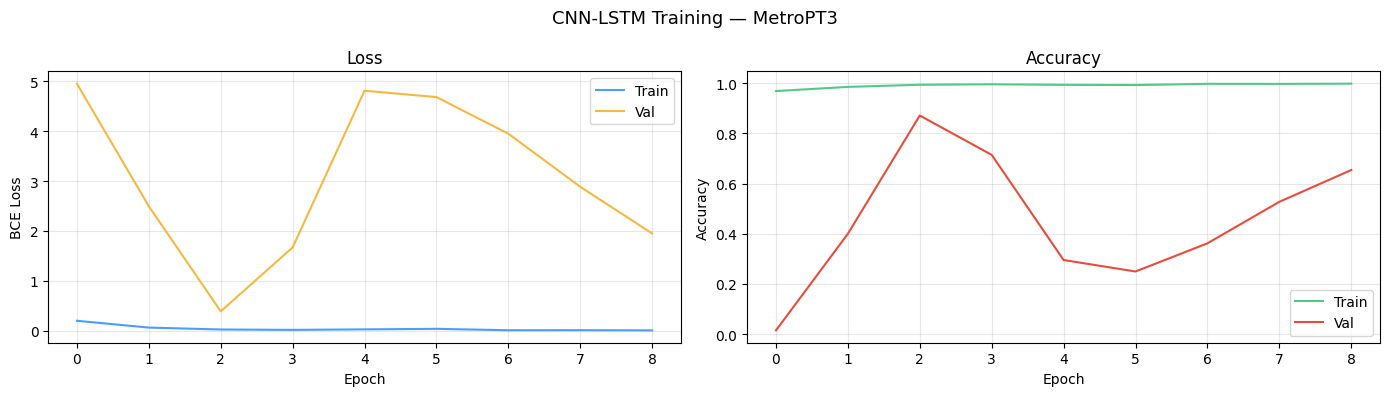

Training complete


In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

print(f"Training on {len(X_tr):,} sequences | BATCH={BATCH_SIZE} | max EPOCHS={EPOCHS}\n")
history = model.fit(
    X_tr, y_tr,
    validation_split = 0.1,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    class_weight     = class_weight,
    callbacks        = callbacks,
    verbose          = 1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"],     label="Train", color="#4a9eff")
axes[0].plot(history.history["val_loss"], label="Val",   color="#f5b942")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="BCE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"],     label="Train", color="#52c98a")
axes[1].plot(history.history["val_accuracy"], label="Val",   color="#e74c3c")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("CNN-LSTM Training — MetroPT3", fontsize=13)
plt.tight_layout()
plt.savefig("output/cnn_lstm_training_metropt3.png", dpi=150)
plt.show()
print("Training complete")

## 6. Evaluation & Results

  CNN-LSTM HYBRID RESULTS — MetroPT3
  Precision : 1.0000  (100.0%)
  Recall    : 0.9094  (90.9%)
  F1 Score  : 0.9525  (95.3%)
  ROC-AUC   : nan
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
     Anomaly       1.00      0.91      0.95     37567

    accuracy                           0.91     37567
   macro avg       0.50      0.45      0.48     37567
weighted avg       1.00      0.91      0.95     37567



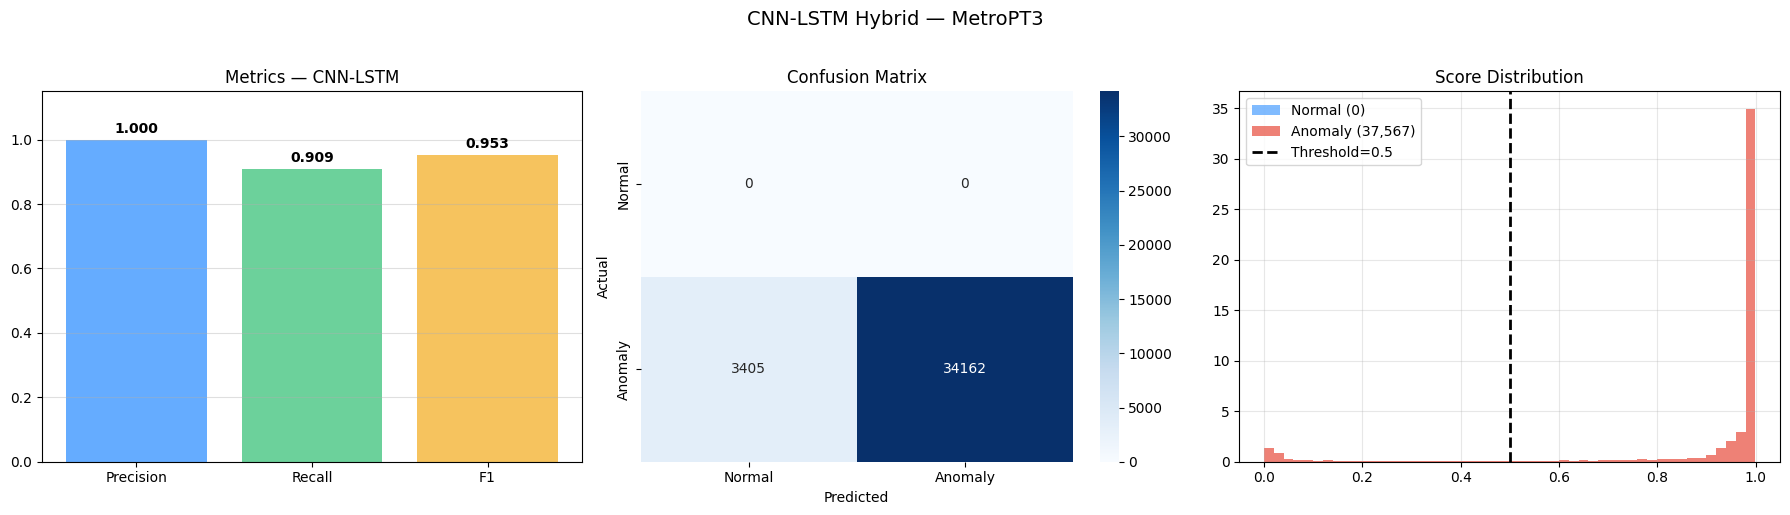

In [ ]:
y_proba = model.predict(X_te, batch_size=512, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

prec = precision_score(y_te, y_pred, zero_division=0)
rec  = recall_score(y_te,  y_pred, zero_division=0)
f1   = f1_score(y_te,   y_pred, zero_division=0)
auc  = roc_auc_score(y_te, y_proba) if y_te.sum()>0 else 0.0

print("="*55)
print("  CNN-LSTM HYBRID RESULTS — MetroPT3")
print("="*55)
print(f"  Precision : {prec:.4f}  ({prec*100:.1f}%)")
print(f"  Recall    : {rec:.4f}  ({rec*100:.1f}%)")
print(f"  F1 Score  : {f1:.4f}  ({f1*100:.1f}%)")
print(f"  ROC-AUC   : {auc:.4f}")
print("="*55)
print(classification_report(y_te, y_pred, target_names=["Normal","Anomaly"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars = axes[0].bar(["Precision","Recall","F1","ROC-AUC"], [prec,rec,f1,auc],
                    color=["#4a9eff","#52c98a","#f5b942","#e74c3c"], alpha=0.85)
axes[0].set_ylim(0, 1.15); axes[0].set_title("Metrics — CNN-LSTM")
axes[0].grid(axis="y", alpha=0.4)
for b,v in zip(bars,[prec,rec,f1,auc]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
                 f"{v:.3f}", ha="center", fontweight="bold")

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Anomaly"],
            yticklabels=["Normal","Anomaly"], ax=axes[1])
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

axes[2].hist(y_proba[y_te==0], bins=50, alpha=0.7, color="#4a9eff",
             label=f"Normal ({(y_te==0).sum():,})", density=True)
if y_te.sum()>0:
    axes[2].hist(y_proba[y_te==1], bins=50, alpha=0.7, color="#e74c3c",
                 label=f"Anomaly ({y_te.sum():,})", density=True)
axes[2].axvline(0.5, color="black", lw=2, ls="--", label="Threshold=0.5")
axes[2].set_title("Score Distribution"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("CNN-LSTM Hybrid — MetroPT3", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("output/cnn_lstm_results_metropt3.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Save Model

In [ ]:
model.save("model/MetroPT3/cnn_lstm.keras")
joblib.dump(scaler,    "model/MetroPT3/scaler.pkl")
joblib.dump(feat_cols, "model/MetroPT3/feature_cols.pkl")

metrics = {
    "model": "CNN-LSTM", "dataset": "MetroPT3",
    "precision": round(float(prec),4), "recall": round(float(rec),4),
    "f1": round(float(f1),4), "roc_auc": round(float(auc),4),
    "timesteps": TIMESTEPS, "n_features": n_features,
}
with open("model/MetroPT3/cnn_lstm_metrics.json","w") as fp:
    json.dump(metrics, fp, indent=2)

print("Saved to model/MetroPT3/")
print(json.dumps(metrics, indent=2))